Counts matrix:
[[ 83 264]
 [415  73]]

Fraction matrix, row-normalized:
[[0.23919308 0.76080692]
 [0.85040984 0.14959016]]

Accuracy      = 0.8132
CC efficiency = 0.7608
ES efficiency = 0.8504


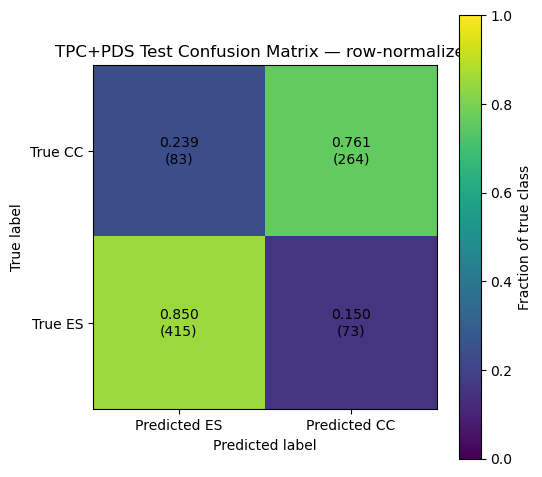

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

OUTFILE = "/home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep40_bs64_test_predictions.h5"
TITLE = "TPC+PDS Test Confusion Matrix"

#OUTFILE = "/home/apaudel/NuGraph/scripts/merged1_July3_tpc_only_ep45_bs64_test_predictions.h5"
#TITLE = "TPC-only Test Confusion Matrix"

with h5py.File(OUTFILE, "r") as f:
    table = f["events/table"][()]

int_block = table["values_block_0"]

# last two integer columns are truth label and predicted label
# 0 = ES, 1 = CC
y_true = int_block[:, -2].astype(int)
y_pred = int_block[:, -1].astype(int)

# Desired display order:
# Y-axis rows: True CC, True ES
# X-axis cols: Predicted ES, Predicted CC
row_labels = [1, 0]   # CC, ES
col_labels = [0, 1]   # ES, CC

cm_counts = np.zeros((2, 2), dtype=int)

for i, true_label in enumerate(row_labels):
    for j, pred_label in enumerate(col_labels):
        cm_counts[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))

# Normalize each TRUE row
row_sums = cm_counts.sum(axis=1, keepdims=True)
cm_frac = cm_counts / row_sums

accuracy = np.mean(y_true == y_pred)

# With this axis order:
# CC efficiency is top-right
# ES efficiency is bottom-left
cc_eff = cm_frac[0, 1]
es_eff = cm_frac[1, 0]

print("Counts matrix:")
print(cm_counts)

print("\nFraction matrix, row-normalized:")
print(cm_frac)

print(f"\nAccuracy      = {accuracy:.4f}")
print(f"CC efficiency = {cc_eff:.4f}")
print(f"ES efficiency = {es_eff:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))

im = ax.imshow(cm_frac, vmin=0, vmax=1)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted ES", "Predicted CC"])
ax.set_yticklabels(["True CC", "True ES"])

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(TITLE + " — row-normalized")

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            f"{cm_frac[i, j]:.3f}\n({cm_counts[i, j]})",
            ha="center",
            va="center"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fraction of true class")

plt.tight_layout()
plt.show()